In [4]:
dataset_name='EthanolConcentration'

patch_size=64
patch_stride=16
T=24
length=1751
n_classes=4
num_channels=3

In [5]:
dataset_name='Heartbeat'
patch_size=24
patch_stride=16
T=24
length=405
n_classes=2
num_channels=61

In [1]:
dataset_name='JapaneseVowels'
patch_size=8
patch_stride=2
T=24
length=29
n_classes=9
num_channels=12

In [2]:
from data_provider.data_factory import data_provider
import torch
import matplotlib.pyplot as plt
import math

class Args:
    def __init__(self):
        self.seed = 42
        self.gating = 'original'
        self.log_dir = dataset_name
        self.num_workers = 16
        self.attn = 'SSA'
        self.test = True
        self.print_epoch = 1
        self.nd = 1
        self.e = 50
        self.warm_up_epoch = 30
        self.num_channels = num_channels
        self.batch_size = 16
        self.lr = 0.001
        self.max_lr = 0.01
        self.emb = 512
        self.nh = 8
        self.layers = 1
        self.time_layers = 7
        self.alpha = 0.1
        self.patch_size = patch_size
        self.patch_stride = patch_size // 2
        self.T = T
        self.no_bias = True
        self.scheduler = 'cosine'
        self.num_classes = n_classes
        self.data_path = 'JapaneseVowels'
        self.data = 'UEA'
        self.root_path = '/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/classification/dataset/JapaneseVowels/'
        self.seq_len = length
        self.segment_len = 0
        self.task_name = 'classification'
        self.augmentation_ratio = 0
        self.jitter = False
        self.scaling = False
        self.permutation = False
        self.randompermutation = False
        self.magwarp = False
        self.timewarp = False
        self.windowslice = False
        self.windowwarp = False
        self.rotation = False
        self.spawner = False
        self.dtwwarp = False
        self.shapedtwwarp = False
        self.wdba = False
        self.discdtw = False
        self.discsdtw = False
        self.extra_tag = ""

args = Args()

train_data, train_loader = data_provider(args, flag='TRAIN')
val_data, val_loader = data_provider(args, flag='TEST')

/home/yschoi/.conda/envs/snn_jelly/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


270
370


In [4]:
def dct_matrix(T: int, device=None, dtype=torch.float32):
    device = device or 'cpu'
    n = torch.arange(T, device=device, dtype=dtype).reshape(1, T)
    k = torch.arange(T, device=device, dtype=dtype).reshape(T, 1)
    C = torch.cos(math.pi * (n + 0.5) * k / T) * math.sqrt(2.0 / T)
    C[0, :] *= 1 / math.sqrt(2.0)
    return C  # (T,T)

def dct_time(x: torch.Tensor, C: torch.Tensor, time_dim: int = 1):
    # (B,T,D) 가정 버전
    if time_dim != 1:
        perm = list(range(x.dim()))
        perm[1], perm[time_dim] = perm[time_dim], perm[1]
        x = x.permute(*perm).contiguous()
        need_inv = (perm != list(range(len(perm))))
    else:
        need_inv = False

    Y = torch.matmul(x.transpose(1, 2).contiguous(), C.t()).transpose(1, 2)

    if need_inv:
        inv = list(range(len(perm)))
        inv[1], inv[time_dim] = inv[time_dim], inv[1]
        Y = Y.permute(*inv).contiguous()
    return Y

def idct_time(xc: torch.Tensor, C: torch.Tensor, time_dim: int = 1):
    if time_dim != 1:
        perm = list(range(xc.dim()))
        perm[1], perm[time_dim] = perm[time_dim], perm[1]
        xc = xc.permute(*perm).contiguous()
        need_inv = (perm != list(range(len(perm))))
    else:
        need_inv = False

    Y = torch.matmul(xc.transpose(1, 2).contiguous(), C).transpose(1, 2)

    if need_inv:
        inv = list(range(len(perm)))
        inv[1], inv[time_dim] = inv[time_dim], inv[1]
        Y = Y.permute(*inv).contiguous()
    return Y

def lowpass_memory(x_bin: torch.Tensor,
                         keep_ratio: float = 0.25,
                         time_dim: int = 1,
                         center: bool = True,
                         rebinarize: bool = False,
                         thresh: float = 0.5):
    """
    x_bin: (B,T,D) 바이너리 스파이크(0/1) 또는 {0,1}로 해석 가능한 텐서
    return: x_lp (연속 또는 재이산화), coeff_lp (저주파만 남긴 DCT 계수)
    """
    x = x_bin.to(dtype=torch.float32)
    T = x.shape[time_dim]
    C = dct_matrix(T, device=x.device, dtype=x.dtype)

    # (선택) 평균 제거: DC가 너무 크면 저역만 남길 때 정보가 평준화됨
    if center:
        mean = x.mean(dim=time_dim, keepdim=True)
        x = x - mean

    # DCT
    Xc = dct_time(x, C, time_dim=time_dim)

    # 저주파 유지
    k = max(1, int(math.ceil(T * keep_ratio)))
    mask = torch.zeros(T, device=x.device, dtype=x.dtype)
    mask[:k] = 1
    shp = [1] * x.dim()
    shp[time_dim] = T
    mask = mask.view(*shp)
    Xc_lp = Xc * mask

    # 역변환
    x_lp = idct_time(Xc_lp, C, time_dim=time_dim)

    # (선택) 평균 복원: 장기 추세를 살리고 싶다면
    if center:
        x_lp = x_lp + mean

    # (선택) 재이산화: 추론용/스파이크 유지가 필요할 때만
    if rebinarize:
        # 주의: 역전파 필요하면 STE 등으로 처리
        x_lp = (x_lp > thresh).to(x.dtype)

    return x_lp, Xc_lp, mask


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. 배치 하나 가져오기
# -------------------------

x = next(iter(train_loader))[0]

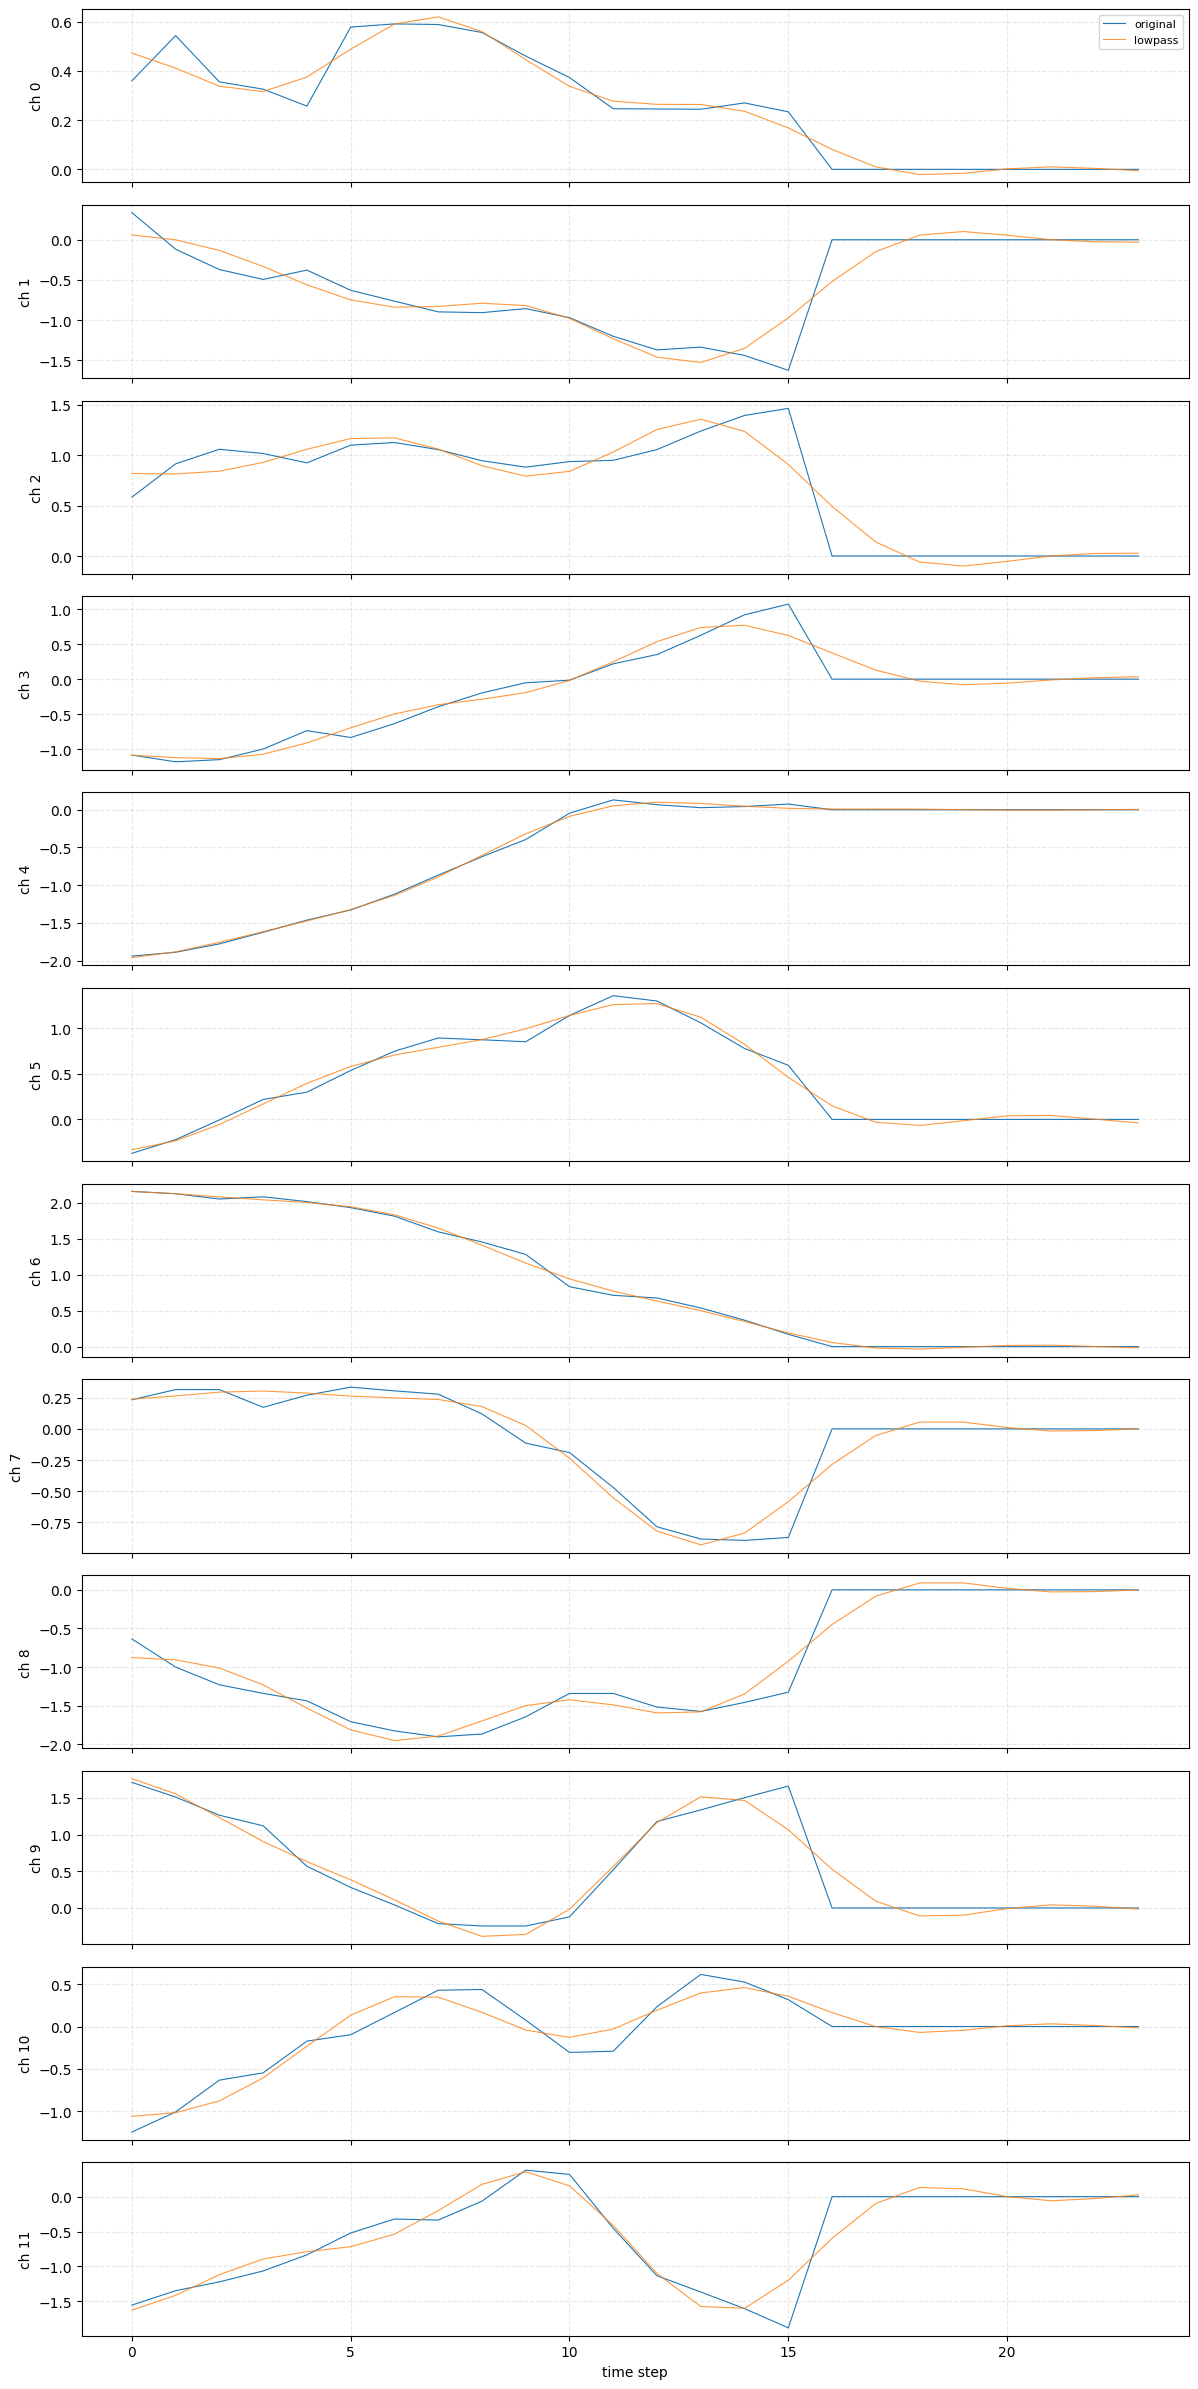

In [8]:

ll = 24
x_sample    = x[10, :ll, :]
x_lp_sample,  *_ = lowpass_memory(
                                    x_sample.unsqueeze(0),
                                    keep_ratio=0.3,   # 필요에 따라 조절
                                    time_dim=1,
                                    center=True,
                                    rebinarize=False
                                )
x_lp_sample = x_lp_sample.squeeze(0)

if x_sample.dim() != 2:
    raise ValueError(f"x_sample은 [L, M] 2D여야 합니다. 현재 shape: {x_sample.shape}")

L, M = x_sample.shape
time = np.arange(L)

# numpy로 변환
x_np    = x_sample.detach().cpu().numpy()      # [L, M]
x_lp_np = x_lp_sample.detach().cpu().numpy()   # [L, M]

# -------------------------
# 4. 채널별 subplot
# -------------------------
fig, axes = plt.subplots(
    nrows=M,
    ncols=1,
    figsize=(12, 2 * M),
    sharex=True
)

if M == 1:
    axes = [axes]

for ch in range(M):
    ax = axes[ch]
    orig_ts = x_np[:, ch]
    lp_ts   = x_lp_np[:, ch]

    ax.plot(time, orig_ts, label='original', linewidth=0.8)
    ax.plot(time, lp_ts, label='lowpass', linewidth=0.8, alpha=0.8)

    ax.set_ylabel(f'ch {ch}')
    ax.grid(True, linestyle='--', alpha=0.3)

    if ch == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('time step')
plt.tight_layout()
plt.show()


In [18]:
color = ["#66C5CC","#F6CF71","#F89C74","#DCB0F2","#87C55F","#9EB9F3","#FE88B1","#C9DB74","#8BE0A4","#B497E7","#D3B484","#B3B3B3"]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
def plot_uea_avg_accuracy_bar(
    dummy_for_missing=0.0,
    show_values=True
):
    """
    Horizontal bar plot for average accuracy on UEA datasets.
    - y-axis: model names
    - x-axis: average accuracy (%)
    - Models without reported average use `dummy_for_missing`.
    """
    # Averages from your table
    models = [
        "NSMT",
        "Informer",
        "Autoformer",
        "FEDformer",
        "ETSformer",
        "PatchTST",
    ]

    avg_acc = [
        61.6,
        53.0,  # Informer (Avg.)
        61.5,  # Autoformer (Avg.)
        59.5,  # FEDformer (Avg.)
        58.8,  # ETSformer (Avg.)
        61.4,  # PatchTST (Avg.)
    ]

    # Fill missing with dummy
    avg_acc = [dummy_for_missing if v is None else v for v in avg_acc]

    y = np.arange(len(models))

    order = np.argsort(avg_acc)[::-1]
    models_sorted = [models[i] for i in order]
    avg_sorted = [avg_acc[i] for i in order]

    y = np.arange(len(models_sorted))

    # Different color per bar (no fixed palette; matplotlib default cycle)
    # colors = [f"C{i % 10}" for i in range(len(models_sorted))]
    colors = ["#66C5CC","#F6CF71","#F89C74","#DCB0F2","#87C55F","#9EB9F3","#FE88B1","#C9DB74","#8BE0A4","#B497E7","#D3B484","#B3B3B3"]
    fig = plt.figure(figsize=(6, 3))
    plt.barh(y, avg_sorted, height=0.6, color=colors)
    plt.yticks(y, models_sorted)
    plt.xlabel("Average Accuracy (%)")
    # plt.title("UEA Classification: Average Accuracy by Model")

    # Put the best on top
    plt.gca().invert_yaxis()

    # Add a little margin on the right so text doesn't get clipped
    mx = max(avg_sorted) if len(avg_sorted) > 0 else 1.0
    plt.xlim(0, mx * 1.15)

    # Annotate values
    if show_values:
        for i, v in enumerate(avg_sorted):
            fw = "bold" if models_sorted[i] == "NSMT" else "normal"
            plt.text(
                v + mx * 0.01, i, f"{v:.1f}",
                va="center",
                fontweight=fw
            )

    plt.tight_layout()
    plt.savefig("UEA_classification_summary.pdf", dpi=1200)
    plt.show()

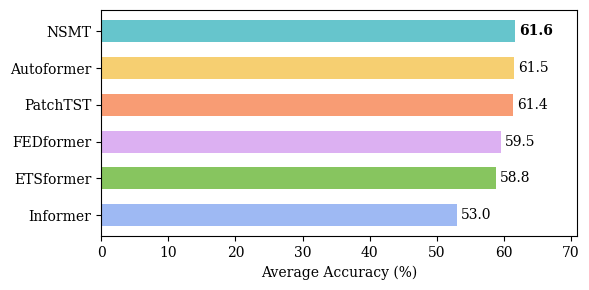

In [4]:

# Run
plot_uea_avg_accuracy_bar(dummy_for_missing=0.0)
